# V2 Walking Walkthrough — Defensive Playcall Causal RL

**"Right Tools, Simple Problem."** Same one-team problem as V1, but the deliberately-wrong
skeleton parts are replaced with the real machinery: a **calibrated** behavior model,
a per-treatment **GBM outcome model**, a **doubly-robust** off-policy evaluator, a
**conservative** policy, and a **sensitivity analysis** that bounds unobserved confounding.
Every estimate below is stamped with the causal graph it assumed, and the last step is a
**regression gate** that makes V2 earn its place against V1 on held-out data.

**Scope:** all downs · SF defense · 2021–2023 · **12 actions** = 6 coverage shells
{C0, C1, C2, C3, C4, C6} × {blitz, no-blitz}.

This notebook narrates the pipeline on **real SF nflfastR data**, then validates the OPE
machinery against a **known synthetic SCM** where the right answer is knowable. V1 is
preserved at git tag `v1` (`git checkout v1`).

## Setup

In [1]:
import os, sys, warnings, logging

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
logging.disable(logging.WARNING)  # quiet DoWhy / LightGBM chatter

# Put the repo root (the directory containing configs/) on the import path so the
# `from src...` imports resolve. Must run before those imports.
here = os.getcwd()
root = here if os.path.exists(os.path.join(here, "configs")) else os.path.dirname(here)
os.chdir(root); sys.path.insert(0, root)

# Project pipeline — one import per component, in the order the notebook uses them.
from src.data.load import load_pbp, generate_synthetic, true_policy_value
from src.data.features import build_dataset, time_aware_split
from src.scm import graph as scm
from src.scm import identify
from src.models.behavior.propensity import fit_behavior_model
from src.models.outcome.q_model import fit_q_model, crossfit_q
from src.ope.direct_method import behavior_recovery_check, dm_policy_value
from src.ope.doubly_robust import dr_policy_value
from src.ope.aipw import aipw_contrasts
from src.ope.sensitivity import sensitivity_bounds, attach as attach_sensitivity
from src.policy.conservative import learn_conservative_policy
from src.evaluation import compare_v1_to_v2

In [2]:
pd.set_option("display.float_format", lambda v: f"{v:+.4f}")

with open("configs/v2.yaml") as f:
    cfg = yaml.safe_load(f)
np.random.seed(cfg["seed"])
WEIGHT_CLIP = cfg["ope"]["weight_clip"]
cfg["data"]["team"], cfg["data"]["down"], cfg["data"]["seasons"], cfg["data"]["holdout_season"]

('SF', 'all', [2021, 2022, 2023], 2023)

## Step 1 — Data layer: raw play-by-play → 12-action (S, A, R)

Filter to SF defensive snaps on **all downs**, label the treatment as
`coverage shell × pressure` (12 actions), and engineer a **strictly pre-snap** state
including leak-free rolling proxies (offensive pass tendency, QB / unit historical EPA).
Off-taxonomy coverages (NaN / PREVENT / 2-Man) are dropped. Side note: we lose about half of the plays in the dataset with this filtering.

In [3]:
pbp = load_pbp(cfg["data"]["seasons"], cfg["data"]["cache_dir"])   # cached parquet
ds = build_dataset(pbp, cfg)
print(f"{len(pbp):,} raw plays  ->  {len(ds.df):,} SF charted plays, {ds.n_actions} actions")
ds.df[["season", "down", "ydstogo", "yardline_100", "action_label", "reward"]].head()

149,021 raw plays  ->  2,008 SF charted plays, 12 actions


,season,down,ydstogo,yardline_100,action_label,reward
0,2021,+1.0000,+10.0000,+65.0000,cover1_blitz,-1.2230
1,2021,+2.0000,+8.0000,+41.0000,cover3_blitz,+0.8532
2,2021,+3.0000,+8.0000,+41.0000,cover3_no_blitz,+0.2826
3,2021,+1.0000,+10.0000,+25.0000,cover3_no_blitz,+0.4661
4,2021,+2.0000,+10.0000,+25.0000,cover6_no_blitz,+1.8965


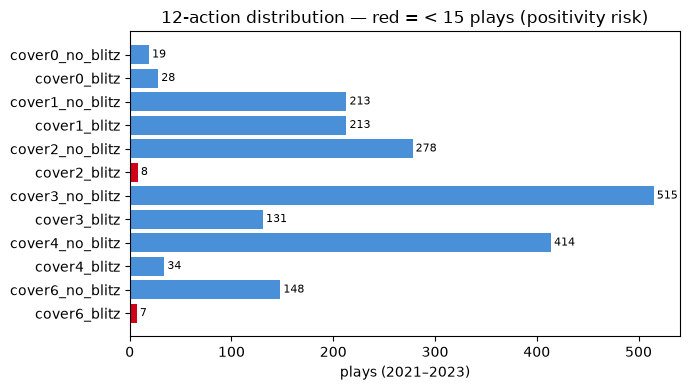

In [4]:
# Action distribution — note the sparsity: some coverage x blitz cells are tiny.
counts = ds.df["action"].value_counts().reindex(range(ds.n_actions), fill_value=0)
labels = [ds.action_labels[a] for a in range(ds.n_actions)]
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#D0021B" if c < 15 else "#4A90D9" for c in counts.values]
ax.barh(labels, counts.values, color=colors)
ax.invert_yaxis(); ax.set_xlabel("plays (2021–2023)")
ax.set_title("12-action distribution — red = < 15 plays (positivity risk)")
for i, c in enumerate(counts.values):
    ax.text(c + 3, i, str(c), va="center", fontsize=8)
plt.tight_layout(); plt.show()

Already the central V2 tension is visible: with one team's charted data, several
`coverage × blitz` combinations have only a handful of plays. That
sparsity drives everything downstream (calibration, positivity, CI width).

In [5]:
# Time-aware split — never random across plays (avoids temporal leakage).
train, test = time_aware_split(ds, cfg["data"]["holdout_season"])
print(f"train {len(train.df):,} plays (< {cfg['data']['holdout_season']})   "
      f"holdout {len(test.df):,} plays (>= {cfg['data']['holdout_season']})")

train 1,296 plays (< 2023)   holdout 712 plays (>= 2023)


## Step 2 — Causal graph + identification (DoWhy)

The hand-built DAG in `src/scm/graph.py` is the single source of truth for what every
downstream model conditions on: the **adjustment set** (observed confounders + player
proxies) blocks the backdoor path `def_playcall → epa`; the offensive playcall is a
post-snap **mediator** we must *not* condition on; `coach_read` is the **unobserved**
confounder the sensitivity analysis bounds.

In [6]:
print(scm.describe())

V2 SCM [v2.0+0bfe436abac7]: treatment=def_playcall, outcome=epa
  adjustment set (condition on): ['game_state', 'off_formation', 'off_personnel', 'off_tendencies', 'player_proxies']
    -> 22 feature columns
  mediators (do NOT condition on): ['off_playcall']
  unobserved confounders: ['coach_read'] (bounded by the sensitivity analysis)


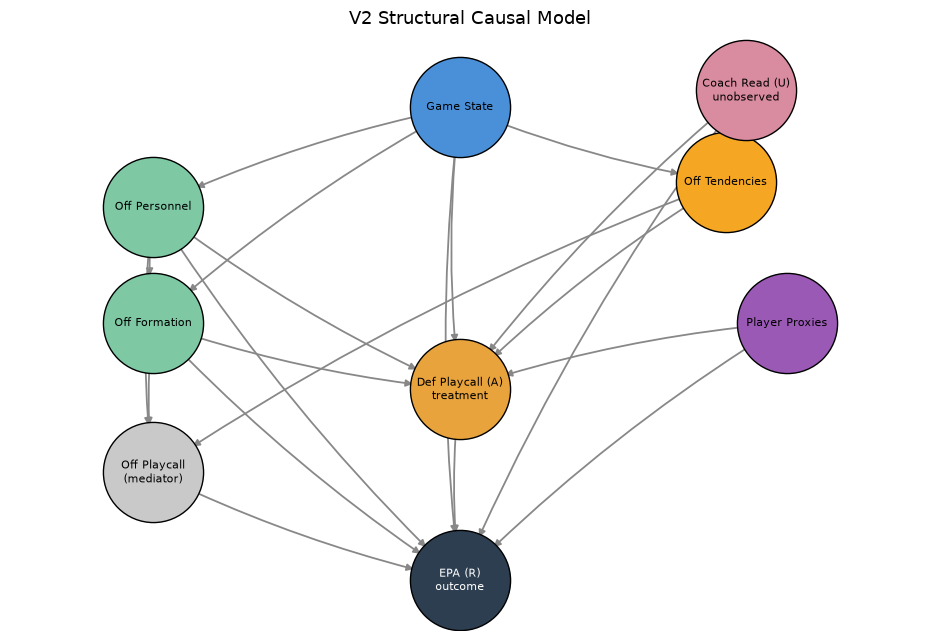

In [7]:
# Draw the V2 DAG (hand layout for readability).
pos = {"game_state": (0, 3), "off_personnel": (-3, 1.8), "off_formation": (-3, 0.4),
       "off_tendencies": (2.6, 2.1), "player_proxies": (3.2, 0.4),
       "coach_read": (2.8, 3.2), "off_playcall": (-3, -1.4),
       "def_playcall": (0, -0.4), "epa": (0, -2.7)}
labels = {"game_state": "Game State", "off_personnel": "Off Personnel",
          "off_formation": "Off Formation", "off_tendencies": "Off Tendencies",
          "player_proxies": "Player Proxies", "coach_read": "Coach Read (U)\nunobserved",
          "off_playcall": "Off Playcall\n(mediator)", "def_playcall": "Def Playcall (A)\ntreatment",
          "epa": "EPA (R)\noutcome"}
colors = {"game_state": "#4A90D9", "off_personnel": "#7EC8A4", "off_formation": "#7EC8A4",
          "off_tendencies": "#F5A623", "player_proxies": "#9B59B6",
          "coach_read": "#D98BA0", "off_playcall": "#C9C9C9",
          "def_playcall": "#E8A33D", "epa": "#2C3E50"}
fig, ax = plt.subplots(figsize=(9.5, 6.5))
for s, t in scm.EDGES:
    x0, y0 = pos[s]; x1, y1 = pos[t]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), zorder=1,
                arrowprops=dict(arrowstyle="-|>", lw=1.3, color="#888",
                                shrinkA=34, shrinkB=34,
                                connectionstyle="arc3,rad=0.06"))
for n, (x, y) in pos.items():
    fc = "white" if n == "epa" else "k"
    ax.scatter([x], [y], s=5200, c=colors[n], zorder=3, edgecolors="k")
    ax.text(x, y, labels[n], ha="center", va="center", fontsize=8, color=fc, zorder=4)
ax.set_xlim(-4.4, 4.6); ax.set_ylim(-3.3, 3.9); ax.axis("off")
ax.set_title("V2 Structural Causal Model", fontsize=13); plt.tight_layout(); plt.show()

In [8]:
# DoWhy: confirm the effect is backdoor-identified by the adjustment set.
model = identify.build_causal_model(train)
est = identify.identify_estimand(model)
print(f"backdoor-identified via {len(est.get_backdoor_variables())} adjustment variables")

backdoor-identified via 22 adjustment variables


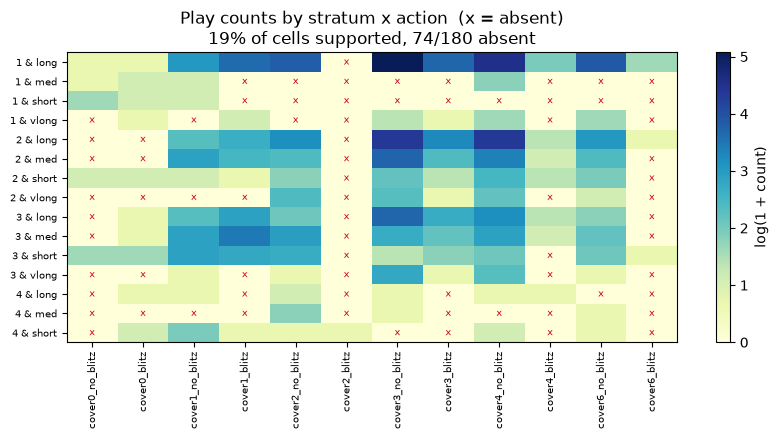

In [9]:
# Positivity: per (down x distance) stratum, how many of the 12 calls have support?
pos = identify.check_positivity(train, cfg["positivity"]["min_count"])
cov = pos["coverage"]
mat = cov[[c for c in cov.columns if isinstance(c, int)]].to_numpy(dtype=float)
strata = cov["_down_bin"].astype(str) + " & " + cov["_dist_bin"].astype(str)
fig, ax = plt.subplots(figsize=(8.5, 4.5))
im = ax.imshow(np.log1p(mat), aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(ds.n_actions)); ax.set_xticklabels(
    [ds.action_labels[a] for a in range(ds.n_actions)], rotation=90, fontsize=7)
ax.set_yticks(range(len(strata))); ax.set_yticklabels(strata, fontsize=7)
# mark structurally-absent cells
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        if mat[i, j] == 0:
            ax.text(j, i, "x", ha="center", va="center", color="#D0021B", fontsize=7)
ax.set_title(f"Play counts by stratum x action  (x = absent)\n"
             f"{pos['pct_cells_supported']:.0%} of cells supported, "
             f"{pos['n_absent_cells']}/{pos['n_cells']} absent")
fig.colorbar(im, ax=ax, label="log(1 + count)"); plt.tight_layout(); plt.show()

The red `x`s are **positivity holes**, which are states where a call was never observed, so no model can vouch for it. The conservative policy is forbidden from recommending there.

## Step 3 — Behavior policy π_b(A | S): calibrated LightGBM

π_b is the engine of inverse-weighting, so **calibration matters more than accuracy**.
On dense data we isotonic-calibrate with cross-fitting; when a call is too rare to
cross-validate (a single play), the model **falls back to uncalibrated** recommendations rather than crashing.

In [10]:
beh, diag = fit_behavior_model(train, cfg)
print("calibrated:" , diag["calibrated"], "| diagnostics:", diag["diagnostics_source"],
      "| rarest class count:", diag["min_class_count"])
print(f"accuracy {diag['oof_accuracy']:.3f}  (majority {diag['majority_baseline']:.3f})")
print(f"log loss {diag['oof_log_loss']:.3f}   ECE {diag['ece']:.3f}   ESS ratio {diag['ess_ratio']:.3f}")

calibrated: True | diagnostics: oof | rarest class count: 1
accuracy 0.336  (majority 0.284)
log loss 1.818   ECE 0.238   ESS ratio 0.282


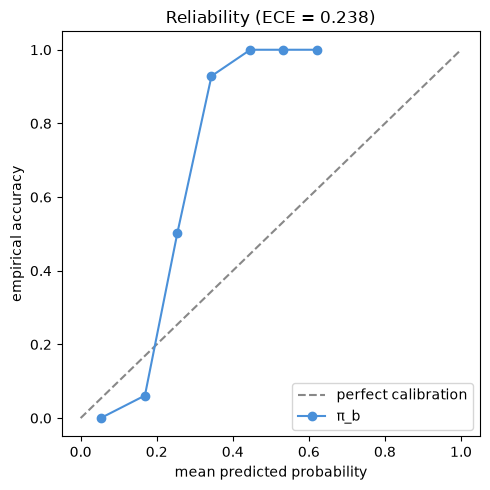

In [11]:
# Reliability diagram: predicted prob of the taken call vs realized frequency.
proba = beh.propensity(train.df)
y = train.df["action"].to_numpy()
conf = proba[np.arange(len(y)), y]
bins = np.linspace(0, 1, 11)
idx = np.digitize(conf, bins) - 1
xs, ys = [], []
for b in range(10):
    m = idx == b
    if m.sum() > 5:
        xs.append(conf[m].mean())
        ys.append((proba.argmax(1)[m] == y[m]).mean())
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", color="#888", label="perfect calibration")
ax.plot(xs, ys, "o-", color="#4A90D9", label="π_b")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("empirical accuracy")
ax.set_title(f"Reliability (ECE = {diag['ece']:.3f})"); ax.legend(); plt.tight_layout(); plt.show()

**Read this critically.** The diagnostics above are **cross-fitted**, not in-sample, and that
distinction is the whole point. One coverage x blitz cell holds a single training play, and
`StratifiedKFold` cannot split a class of one — so the tempting shortcut is to fall back to
in-sample predictions for all twelve actions. Doing that reports a model that has *memorised*
its training rows: accuracy near 0.98, and an ESS ratio near 0.93 that says overlap is
excellent. Both are artefacts. `_cv_splits` instead keeps the un-splittable class on the
training side of every fold and cross-fits the rest, which is what the numbers here reflect.

The honest picture is much humbler: accuracy barely clears the majority baseline, and the ESS
ratio sits near 0.28. Predicting one DC's 12-way call from pre-snap state alone is genuinely
hard. Note that this is the number that *bounds how far pi\* may move* — so getting it right
matters more than getting it flattering. This is exactly the condition where inverse-weighting
is fragile, which is *why* the pipeline leans on doubly-robust OPE (next) rather than trusting
propensities alone.


## Step 4 — Outcome / Q-model: Q(S, A) = E[R | S, do(A)]

One gradient-boosted regressor per action, conditioning **only** on the SCM adjustment
set (mediators excluded). Rare-action cells fall back to a mean rather than extrapolating, limiting the off-support blow-up at the source.

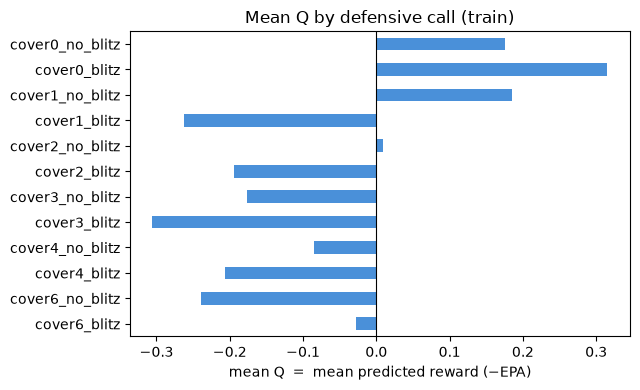

In [12]:
q = fit_q_model(train, cfg)
mean_q = pd.Series({ds.action_labels[a]: q.predict_all_actions(train.df)[:, a].mean()
                    for a in range(ds.n_actions)})
fig, ax = plt.subplots(figsize=(6.5, 4))
mean_q.plot.barh(ax=ax, color="#4A90D9")
ax.axvline(0, color="k", lw=0.8); ax.invert_yaxis()
ax.set_xlabel("mean Q  =  mean predicted reward (−EPA)")
ax.set_title("Mean Q by defensive call (train)"); plt.tight_layout(); plt.show()

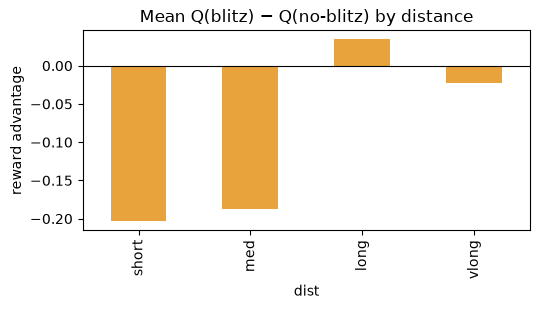

In [13]:
# Does Q vary sensibly with situation? Blitz value by distance bucket.
tmp = test.df.copy()
tmp["dist"] = pd.cut(tmp["ydstogo"], [0, 3, 7, 15, 100], labels=["short", "med", "long", "vlong"])
qall = q.predict_all_actions(test.df)
blitz_cols = [a for a in range(ds.n_actions) if a % 2 == 1]
noblitz_cols = [a for a in range(ds.n_actions) if a % 2 == 0]
tmp["blitz_adv"] = qall[:, blitz_cols].mean(1) - qall[:, noblitz_cols].mean(1)
tmp.groupby("dist")["blitz_adv"].mean().plot.bar(
    color="#E8A33D", figsize=(5.5, 3.2), title="Mean Q(blitz) − Q(no-blitz) by distance")
plt.axhline(0, color="k", lw=0.8); plt.ylabel("reward advantage"); plt.tight_layout(); plt.show()

## Step 5 — Off-policy evaluation (doubly robust) & the smoke test

The mandatory gate before trusting any policy estimate: **DR under π_b must recover the
empirical mean reward.** We use out-of-fold Q on the training rows so the check is honest.

In [14]:
mu_train = crossfit_q(train, cfg)   # out-of-fold Q for an honest in-sample check
rec = behavior_recovery_check(train, q, beh, q_all=mu_train, weight_clip=WEIGHT_CLIP)
print(f"empirical reward : {rec['empirical_reward']:+.4f}  (± {rec['empirical_se']:.4f})")
print(f"DM under π_b     : {rec['dm_under_pi_b']:+.4f}")
print(f"DR under π_b     : {rec['dr_under_pi_b']:+.4f}")
print(f"recovery gap (DR): {rec['recovery_gap']:.4f}  ->  {'PASS' if rec['passes'] else 'FAIL'}")

empirical reward : -0.0889  (± 0.0446)
DM under π_b     : -0.0931
DR under π_b     : -0.1030
recovery gap (DR): 0.0140  ->  PASS


If DR recovers π_b's known value, the OPE machinery is self-consistent. Unlike V1's Direct
Method — which extrapolated ridge-Q to implausible off-support values and reported absurd
lift — DR's importance-weighted correction on logged plays anchors the estimate to reality.

## Step 6 — Conservative policy, holdout evaluation & sensitivity

The learned policy is a behavior-regularized (CQL/IQL-style) argmax: it departs from the
DC only when Q is confidently higher **and** the call is well-supported. We evaluate it on
the held-out season with DR, then ask the crucial question: **does the lift survive
unobserved confounding?**

In [15]:
policy = learn_conservative_policy(train, q, beh, cfg)
out = policy.act(test.df)
a_te = test.df["action"].to_numpy(); r_te = test.df["reward"].to_numpy()
q_te = q.predict_all_actions(test.df); pib_te = beh.propensity(test.df)

v_b = dr_policy_value(q_te, pib_te, pib_te, a_te, r_te, WEIGHT_CLIP,
                      policy_name="behavior")
v_pi = dr_policy_value(q_te, pib_te, out["policy_probs"], a_te, r_te, WEIGHT_CLIP,
                       policy_name="conservative")
print(f"V_DR(π_b) : {v_b.value:+.4f}   95% CI [{v_b.ci95[0]:+.4f}, {v_b.ci95[1]:+.4f}]")
print(f"V_DR(π*)  : {v_pi.value:+.4f}   95% CI [{v_pi.ci95[0]:+.4f}, {v_pi.ci95[1]:+.4f}]")
print(f"estimated lift : {v_pi.value - v_b.value:+.4f} reward/play")
print(f"π* agrees with the DC on {(out['chosen'] == a_te).mean():.1%} of holdout plays")

V_DR(π_b) : +0.0721   95% CI [-0.0464, +0.1906]
V_DR(π*)  : +0.2884   95% CI [-0.2086, +0.7854]
estimated lift : +0.2163 reward/play
π* agrees with the DC on 17.4% of holdout plays


,policy,gamma,v_lower,v_upper,width,beats_comparison
0,conservative,+1.0000,+0.2884,+0.2884,+0.0000,True
1,conservative,+1.5000,-0.3332,+0.8840,+1.2172,False
2,conservative,+2.0000,-0.7764,+1.3715,+2.1479,False
3,conservative,+3.0000,-1.3884,+2.2761,+3.6644,False


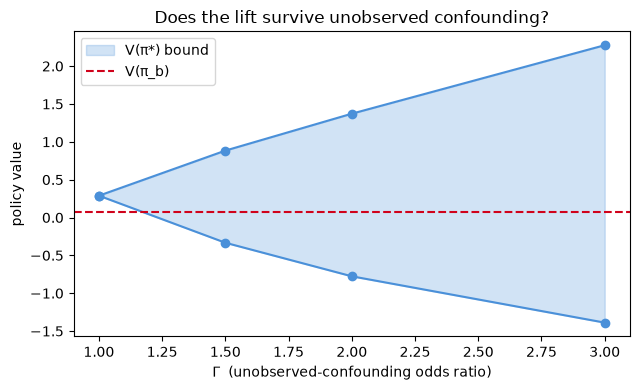

In [16]:
# Rosenbaum / marginal-sensitivity bound: worst-case V(π*) as confounding strength Γ grows.
sens = sensitivity_bounds(q_te, pib_te, out["policy_probs"], a_te, r_te,
                          cfg["sensitivity"]["gamma_range"], WEIGHT_CLIP,
                          compare_value=v_b.value, policy_name="conservative")
display(sens)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.fill_between(sens["gamma"], sens["v_lower"], sens["v_upper"], alpha=0.25,
                color="#4A90D9", label="V(π*) bound")
ax.plot(sens["gamma"], sens["v_lower"], "o-", color="#4A90D9")
ax.plot(sens["gamma"], sens["v_upper"], "o-", color="#4A90D9")
ax.axhline(v_b.value, color="#D0021B", ls="--", label="V(π_b)")
ax.set_xlabel("Γ  (unobserved-confounding odds ratio)"); ax.set_ylabel("policy value")
ax.set_title("Does the lift survive unobserved confounding?"); ax.legend()
plt.tight_layout(); plt.show()

Where the blue band drops below the red π_b line, the estimated improvement is **no longer
robust** — an unobserved read of that strength could explain it away. On sparse single-team
data this typically happens at modest Γ, which is the honest verdict this data supports.
This is the discipline V1 lacked entirely.

## Step 7 — The regression gate: does V2's policy beat V1's?

Every estimate above is a claim about π\*. The project's modeling discipline
(CLAUDE.md) says a new version has to *earn* its place: **"every new model version
evaluated against the previous via OPE on a held-out season; regressions block merge."**

So we score V1's decision rule (behavior-constrained greedy, `argmax_a Q`) and V2's
(conservative, `argmax_a [Q + α·log π_b]`) on the **same** holdout plays, using the same
fitted Q and π_b — that isolates the thing V2 actually changed, the decision rule.

Because both policies are scored on the same rows, the difference is **paired**: the shared
Q/π_b estimation noise cancels rather than adding. That matters a lot here — each policy's
own CI is far wider than the gap between them, so unpaired comparison could resolve nothing.


In [17]:
cmp = compare_v1_to_v2(test, q, beh, cfg)
print(cmp.report())

# The full record that gets written to outputs/version_comparison.csv.
pd.DataFrame([cmp.to_record()]).T.rename(columns={0: "value"})


  V_DR(v1_greedy      ) = +0.2158
  V_DR(v2_conservative) = +0.2884
  paired difference     = +0.0727  95% CI [-0.2384, +0.3837]  (n=712)
  non-inferiority margin= 0.0200
  verdict: NO CHANGE DETECTED  ->  gate passes


,value
baseline,v1_greedy
candidate,v2_conservative
v_baseline,+0.2158
v_candidate,+0.2884
paired_diff,+0.0727
paired_diff_se,+0.1587
diff_ci_lo,-0.2384
diff_ci_hi,+0.3837
margin,+0.0200
n,712


Read the verdict carefully. The gate is **asymmetric on purpose**: it blocks on a
significant *deterioration* past a non-inferiority margin, not on a failure to prove an
improvement. On this data V2's conservative policy lands slightly *above* V1's greedy policy
with a CI comfortably straddling zero — "no change detected".

The CI is wide, and that width is itself informative. With the conservatism penalty scaled to
the Q model's own spread, the two policies now make genuinely different calls; a paired
difference between two policies that agree almost everywhere would look precise while
measuring nothing. **V2's contribution is that the estimate is credible, not that the number
is bigger** — the point estimate is well inside noise, and the gate is what keeps that claim
honest rather than aspirational.


### Every estimate carries its assumptions

An OPE number means nothing without the DAG it assumed. Each `OPEResult` is stamped with the
estimator, the policy valued, and `scm.graph.version_tag()` — the graph version plus a content
fingerprint, so an unversioned edit to the DAG still shows up on every stored estimate. The
sensitivity bound is *attached* to the estimate it qualifies, so the two can't drift apart.


In [18]:
attach_sensitivity(v_pi, sens)   # bind the Γ-bound to the estimate it qualifies
pd.DataFrame([v_b.to_record(), v_pi.to_record()])


,policy,estimator,value,se,ci_lo,ci_hi,n,graph_version,sensitivity_computed,robust_to_gamma
0,behavior,DR-SN,+0.0721,+0.0605,-0.0464,+0.1906,712,v2.0+0bfe436abac7,False,NaN
1,conservative,DR-SN,+0.2884,+0.2536,-0.2086,+0.7854,712,v2.0+0bfe436abac7,True,+1.0000


## Validation aside — recovering ground truth on a known SCM

On real data we can't see the truth. So we validate the OPE machinery on **synthetic data
from a known SCM** (`generate_synthetic`), where the true value of any policy is computable
via `true_policy_value`. Two claims to check: (1) DR recovers a policy's true value, and
(2) DR is **less biased than the Direct Method** when the outcome model is misspecified.

In [19]:
scfg = dict(cfg); scfg["data"] = dict(cfg["data"], team="SYN")
syn = build_dataset(generate_synthetic(9000, 7), scfg)
s_tr, s_te = time_aware_split(syn, cfg["data"]["holdout_season"])
s_beh, _ = fit_behavior_model(s_tr, cfg)
s_q = fit_q_model(s_tr, cfg)
s_pol = learn_conservative_policy(s_tr, s_q, s_beh, cfg)

a = s_te.df["action"].to_numpy(); r = s_te.df["reward"].to_numpy()
qa = s_q.predict_all_actions(s_te.df); pib = s_beh.propensity(s_te.df)
o = s_pol.act(s_te.df)

true_b  = true_policy_value(s_te.df, a)
true_pi = true_policy_value(s_te.df, o["chosen"])
dr_b  = dr_policy_value(qa, pib, pib, a, r, WEIGHT_CLIP).value
dr_pi = dr_policy_value(qa, pib, o["policy_probs"], a, r, WEIGHT_CLIP).value
print(f"behavior     : true {true_b:+.4f}   DR {dr_b:+.4f}")
print(f"conservative : true {true_pi:+.4f}   DR {dr_pi:+.4f}")
print(f"conservative policy genuinely improves true value: {true_pi > true_b}")

behavior     : true +0.0747   DR +0.0552
conservative : true +0.1067   DR +0.1169
conservative policy genuinely improves true value: True


In [20]:
# Double robustness: with a badly misspecified Q (all zeros) but correct propensities,
# DR still recovers π_b's value while the Direct Method collapses to ~0.
bad_q = np.zeros_like(qa)
dm_bad = dm_policy_value(bad_q, pib).value
dr_bad = dr_policy_value(bad_q, pib, pib, a, r, WEIGHT_CLIP).value
print(f"empirical reward : {r.mean():+.4f}")
print(f"DM (bad Q)       : {dm_bad:+.4f}   <- biased")
print(f"DR (bad Q)       : {dr_bad:+.4f}   <- recovered")

empirical reward : +0.0773
DM (bad Q)       : +0.0000   <- biased
DR (bad Q)       : +0.0773   <- recovered


## Example recommendations (holdout states)

In [21]:
rows = []
for i in test.df.sample(6, random_state=0).index:
    row = test.df.loc[[i]]; res = policy.act(row); s = test.df.loc[i]
    a = int(res["chosen"][0])
    rows.append({
        "situation": f"{int(s['down'])} & {s['ydstogo']:.0f}, ball on {100 - s['yardline_100']:.0f}, "
                     f"score {s['score_diff']:+.0f}",
        "recommend": ds.action_labels[a],
        "Q": res["q_all"][0][a],
        "DC called": ds.action_labels[int(s["action"])],
        "# supported": int(res["support"][0].sum()),
    })
pd.DataFrame(rows)

,situation,recommend,Q,DC called,# supported
0,"1 & 10, ball on 25, score -10",cover3_no_blitz,-0.6655,cover2_no_blitz,5
1,"2 & 20, ball on 42, score -14",cover4_no_blitz,+0.0127,cover2_no_blitz,6
2,"3 & 10, ball on 68, score +7",cover3_no_blitz,-0.5754,cover3_blitz,7
3,"2 & 12, ball on 9, score +0",cover3_no_blitz,-0.2832,cover1_blitz,3
4,"3 & 8, ball on 15, score -4",cover1_blitz,+1.7761,cover1_blitz,5
5,"1 & 10, ball on 49, score -11",cover3_blitz,+0.7988,cover6_no_blitz,6


## Summary & what's next (V3)

V2 delivers a **credibly-evaluated** policy: cross-fitted calibrated propensities, a
doubly-robust evaluator that recovers ground truth on the known SCM and fixes V1's
off-support blow-up, a conservative policy whose pessimism is scaled to the Q model's own
units, and a sensitivity analysis reporting whether the lift survives confounding — each
estimate carrying the graph version and sensitivity bound behind it.

Three honest findings, and none is the one we'd have preferred:

1. **One team's 12-action charted data is sparse** — wide CIs, positivity holes, and a lift
   that is not robust to even modest confounding.
2. **pi_b is barely better than guessing the modal call.** Cross-fitted accuracy clears the
   majority baseline only slightly, and the ESS ratio near 0.28 says a minority of plays
   carry most of the inverse-weight. Both numbers looked far healthier before the
   diagnostics were made out-of-fold — which is the more useful lesson.
3. **V2's policy does not measurably beat V1's on the holdout.** The regression gate returns
   *no change detected*. V2's contribution is that the estimate is now **credible, not
   larger** — and the gate is what stops that from being an untested claim.

Also worth stating plainly: this slice is **charted dropbacks**, not every snap. Coverage
labels come from NGS pass charting, so a recommendation here reads "given the offense drops
back", not unconditionally.

V3 attacks the root cause, which is data density: denser labels, multi-team pooling with
embeddings, invariant policy learning, a hierarchical factored policy, the econml CATE
explainability layer, and the standalone **IPW** estimator deferred from V2 — pointless at
this ESS ratio, informative once pooling lifts it.
